In [1]:
import os
import torch
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
#make plots interactive:
%matplotlib inline
from scipy.optimize import linear_sum_assignment
import matplotlib.image as mpimg




<h2 style="color:#007b90">Data Preparation</h2>

In [2]:
#Inputs
base_path = os.getcwd()
data_path = os.path.join(base_path, f"data")
img_path = os.path.join(data_path, 'images')
depth_path = os.path.join(data_path, 'depths')
print(f"The project's root path is '{base_path}'.")
print(f"Reading data from '{data_path}'.")
print(f"Image folder: '{img_path}'.")
print(f"Depth folder: '{depth_path}'.")

#Outputs
out_path = os.path.join(base_path, 'output')
ply_path = os.path.join(out_path, 'point_cloud')
os.makedirs(out_path, exist_ok=True)
os.makedirs(ply_path, exist_ok=True)
print(f"\nCreating directory '{out_path}'.")
print(f"Creating directory '{ply_path}'.")

#Load Data
camera_calibration = np.load(os.path.join(data_path, 'camera_calibration.npy'), allow_pickle=True)
camera_calibration = camera_calibration.item()#get dictionary from numpy array struct
given_features = np.load(os.path.join(data_path, 'given_features.npy'), allow_pickle=True)
camera_movement = np.load(os.path.join(data_path, 'camera_movement.npy'), allow_pickle=True)

print(f"\nCamera Calibration:")
for entry in camera_calibration.items():
    print(f"  {entry[0]}: {entry[1]}")
print(f"Camera Movement: {camera_movement.shape}")#[Cameras-1, 4, 4]
print(f"2D Features (Unsorted): {given_features.shape}")#[Camera_idx, Feature_idx, 2]
plt.close()

The project's root path is 'c:\Users\USER\Desktop\25-26 RPTU\3D CV\proyecto final\project'.
Reading data from 'c:\Users\USER\Desktop\25-26 RPTU\3D CV\proyecto final\project\data'.
Image folder: 'c:\Users\USER\Desktop\25-26 RPTU\3D CV\proyecto final\project\data\images'.
Depth folder: 'c:\Users\USER\Desktop\25-26 RPTU\3D CV\proyecto final\project\data\depths'.

Creating directory 'c:\Users\USER\Desktop\25-26 RPTU\3D CV\proyecto final\project\output'.
Creating directory 'c:\Users\USER\Desktop\25-26 RPTU\3D CV\proyecto final\project\output\point_cloud'.

Camera Calibration:
  distortion_param: [-0.1, 0.02, 0.0, 0.0, -0.01]
  image_height: 551
  image_width: 881
  principal_point: [275.0, 440.0]
  focal_length_mm: 25
  sensor_width_mm: 35
  pixel_ratio: 1.0
  pixel_per_mm: 25.17142857142857
  focal_length_px: 629.2857142857142
Camera Movement: (8, 4, 4)
2D Features (Unsorted): (9, 7, 2)


In [3]:
def sample_image(numpy_image, numpy_sample_grid):
    '''
    This function samples a target image from a source image (numpy_image) based on specified pixel coordinates (numpy_sample_grid).
    Inputs:
        numpy_image: of shape=[H, W, C]. H is the height, W is the width, and C is the color channel of the source image from which color values will be sampled.
        numpy_sample_grid: of shape=[H, W, UV]. H is the height and W is the width of the target image that will be sampled. UV are the pixel locations in the source image from which to sample color values.
    Outputs:
        sampled_image: of shape=[H, W, C]. H is the height, W is the width, and C is the color channel of the target image that was sampled.
    
    The following is a simple toy example to see the behavior of the sample_image function

    example_source = (np.random.rand(110, 220, 3)*255).astype(int) #[110, 220, 3]
    example_grid = np.ones([100, 200, 2]) #[100, 200, 2]
    example_grid[:, :, 1] = 2
    example_target = sample_image(example_source, example_grid) #[100, 200, 3]

    example_target will be of shape [100, 200, 3]
    -> 100, because example_grid has a height of 100
    -> 200, because example_grid has a width of 200
    -> 3, because example_source has a color channel of 3
    print(example_source.shape)

    example_target will contain the value of example_source[2, 1] at every pixel
    -> 2, because example_grid[:, :, 1] has a value of 2 for every pixel
    -> 1, because example_grid[:, :, 0] has a value of 1 for every pixel
    print(example_source[2, 1, 0], "->", np.unique(example_target[:, :, 0]))
    print(example_source[2, 1, 1], "->", np.unique(example_target[:, :, 1]))
    print(example_source[2, 1, 2], "->", np.unique(example_target[:, :, 2]))
    
    '''
    height, width, _ = numpy_image.shape#[H, W, 3]

    #turn numpy array to torch tensor
    torch_sample_grid = torch.from_numpy(numpy_sample_grid)#[H, W, 2]
    #normalize from range (0, width-1) to (0, 1)
    torch_sample_grid[:, :, 0] = torch_sample_grid[:, :, 0] / (width-1)
    #normalize from range (0, height-1) to (0, 1)
    torch_sample_grid[:, :, 1] = torch_sample_grid[:, :, 1] / (height-1)
    #normalize from range (0, 1) to (-1, 1)
    torch_sample_grid = torch_sample_grid*2 -1

    #transform to necessary shapes
    torch_sample_grid = torch_sample_grid.unsqueeze(0)#[1, H, W, 2]
    torch_image = torch.from_numpy(numpy_image).double().permute(2, 0, 1).unsqueeze(0)#[1, 3, H, W]
    #sample image according to sample grid locations from source image
    sampled_image = torch.nn.functional.grid_sample(torch_image, torch_sample_grid, mode='bilinear', padding_mode='zeros', align_corners=True)
    #transform back to numpy image
    sampled_image = sampled_image.squeeze().permute(1, 2, 0).numpy().astype(np.uint8)#[H, W, 3]
    return sampled_image

def ply_creator(input_3d, rgb_data=None, filename='dummy'):
    ''' Creates a colored point cloud that you can visualise using e.g. Meshlab.
    Inputs:
        input_3d: of shape=[N, 3], each row is the 3D coordinate of each point
        rgb_data(optional): of shape=[N, 3], each row is the rgb color value of each point
        filename: file name for the .ply file to be created 
    '''
    assert (input_3d.ndim==2),"Pass 3d points as NumPointsX3 array "
    pre_text1 = """ply\nformat ascii 1.0"""
    pre_text2 = "element vertex "
    pre_text3 = """property float x\nproperty float y\nproperty float z\nproperty uchar red\nproperty uchar green\nproperty uchar blue\nend_header"""
    pre_text22 = pre_text2 + str(input_3d.shape[0])
    pre_text11 = pre_text1
    pre_text33 = pre_text3
    filename = filename + '.ply'
    fid = open(filename, 'w')
    fid.write(pre_text11)
    fid.write('\n')
    fid.write(pre_text22)
    fid.write('\n')
    fid.write(pre_text33)
    fid.write('\n')
    for i in range(input_3d.shape[0]):
        for c in range(3):
            fid.write(str(input_3d[i,c]) + ' ')
        if not rgb_data is None:
            for c in range(3):
                fid.write(str(rgb_data[i,c]) + ' ')
        if i!=input_3d.shape[0]:
            fid.write('\n')
    fid.close()
    return filename 

<h2 style="color:#007b90">Step 1: Undistortion of the RGB Images</h2>

As described in the Given Data section, the RGB images contain lens distortion, while the depth images are already undistorted. To ensure accurate 3D reconstruction, the two modalities must be aligned.

Undistort all RGB images, then visualize one example image before and after undistortion.

Loaded camera_calibration keys: dict_items([('distortion_param', [-0.1, 0.02, 0.0, 0.0, -0.01]), ('image_height', 551), ('image_width', 881), ('principal_point', [275.0, 440.0]), ('focal_length_mm', 25), ('sensor_width_mm', 35), ('pixel_ratio', 1.0), ('pixel_per_mm', 25.17142857142857), ('focal_length_px', 629.2857142857142)])

Intrinsic Matrix K:
 [[629.28571429   0.         440.        ]
 [  0.         629.28571429 275.        ]
 [  0.           0.           1.        ]]
Distortion Coeffs: [-0.1   0.02  0.    0.   -0.01]
Detected images:  9
['00.png', '01.png', '02.png', '03.png', '04.png', '05.png', '06.png', '07.png', '08.png']

Loaded and undistorted 9 images.


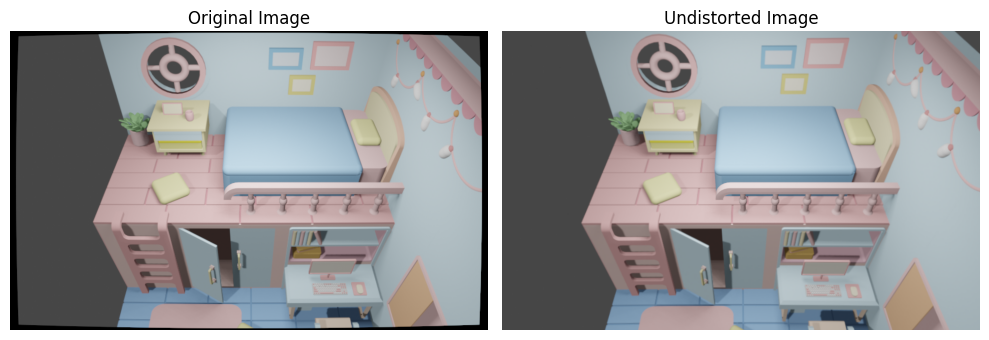

In [4]:
#Data provided in the data preparation cell
print("Loaded camera_calibration keys:", camera_calibration.items())
# Distortion parameters
dist_coeffs = np.array(camera_calibration["distortion_param"], dtype=np.float32)

# Intrinsics
fx = camera_calibration["focal_length_px"]
fy = camera_calibration["focal_length_px"]
cy, cx = camera_calibration["principal_point"]

# Build intrinsic matrix
K = np.array([
    [fx, 0,   cx],
    [0,  fy,  cy],
    [0,   0,   1]
], dtype=np.float64)


print("\nIntrinsic Matrix K:\n", K)
print("Distortion Coeffs:", dist_coeffs)


#LOADING IMAGES 

img_files = sorted([
    f for f in os.listdir(img_path)
])
print("Detected images: ", len(img_files))
print(img_files)

images_original = []
images_undistorted = []

#UNDISTORTING IMAGES (manual sampling grid; avoid OpenCV map creation)
for f in img_files:
    img = cv.imread(os.path.join(img_path, f)) # create full path and load image
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    height, width, _ = img.shape
    images_original.append(img)
    # Manual inverse-distortion mapping: for each pixel (u,v) in the undistorted image compute the
    # corresponding distorted pixel coordinates using the provided distortion coefficients.
    k1, k2, p1, p2, k3 = dist_coeffs.tolist()
    u_coords, v_coords = np.meshgrid(np.arange(width), np.arange(height))  # u: cols, v: rows
    x = (u_coords - cx) / fx
    y = (v_coords - cy) / fy
    r2 = x**2 + y**2
    radial = 1.0 + k1 * r2 + k2 * (r2**2) + k3 * (r2**3)
    x_tang = 2 * p1 * x * y + p2 * (r2 + 2 * x**2)
    y_tang = p1 * (r2 + 2 * y**2) + 2 * p2 * x * y
    x_dist = x * radial + x_tang
    y_dist = y * radial + y_tang
    u_src = x_dist * fx + cx
    v_src = y_dist * fy + cy
    sample_grid = np.stack([u_src, v_src], axis=-1)  # [H, W, 2] with (u, v) pairs
    und_img = sample_image(img, sample_grid)
    images_undistorted.append(und_img)
    # SAVE UNDISTORTED IMAGE
    out_file = os.path.join(out_path, f)
    cv.imwrite(out_file, cv.cvtColor(und_img, cv.COLOR_RGB2BGR))

print(f"\nLoaded and undistorted {len(images_undistorted)} images.")
#VISUALIZE ONE OF THE IMAGES BEFORE AND AFTER THE UNDISTORSION

idx = np.random.randint(0, 9) # The example image that is visualized
    
plt.figure(figsize=(10, 4))

#Visualization of the original image    
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(images_original[idx])
plt.axis("off")
    
#Visualization of the undistorted image
plt.subplot(1, 2, 2)
plt.title("Undistorted Image")
plt.imshow(images_undistorted[idx])
plt.axis("off")
    
plt.tight_layout()
plt.show()


<h2 style="color:#007b90">Step 2: Common Camera Reference Frame</h2>

The provided camera poses are expressed relative to consecutive frames (e.g. the first pose is a transformation from the first view to the second view). However, the final point cloud needs to be definied with respect to a single, common world coordinate system.

Compute camera poses such that they are expressed in terms of a shared world reference frame, and then visualize all camera positions and orientations in a single 3D plot.

Saved 3D camera trajectory plot to: c:\Users\USER\Desktop\25-26 RPTU\3D CV\proyecto final\project\output\camera_trajectory_3D.png


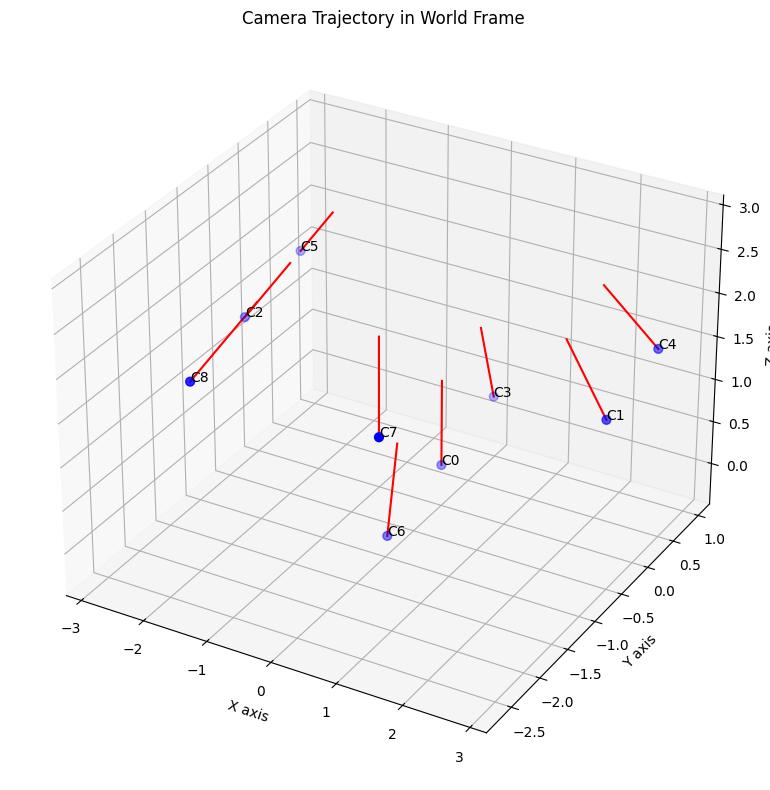

In [5]:
#TRANSFORM RELATIVE POSES TO WORLD-FRAME POSES
def build_world_poses(relative_T):
    """
    Transforms relative poses to camera-to-world poses
    Establishing T_0 as the world coordinates, calculate the consecutive transformations to world poses
    
    Args:
        relative_T : array [N-1, 4, 4]
                       camera_movement array
    
    Returns:
        world_poses : array [N, 4, 4] 
                        camera_to_world poses in each image
    """
    num_rel = relative_T.shape[0] #number of relative matrices
    num_cams = num_rel + 1 #number of images
    world_poses = np.zeros((num_cams, 4, 4))
    
    # We establish the coordinates in the first image as the world coordinates
    world_poses[0] = np.eye(4)

    #Calculate each absolut coordinates (with respect to the world coordinates)
    for i in range(num_rel):
        T_cw = np.linalg.inv(relative_T[i]) #invert the matrix because we calculate the camera-to-world coordinates
        world_poses[i+1] = world_poses[i] @ T_cw
    return world_poses


#DRAW CAMERA AXES
def draw_camera_frame(pose, scale=1):
    """
    Draws the relatice orientation of a camera
    Args:
        pose: 4x4 matrix of a relative pose
        scale: axes length
    """
    origin = pose[:3, 3] #[X, Y, Z] camera center
    R = pose[:3, :3] #3x3 rotation matrix

    direction = R[:,2] #third column
    x_end = origin + direction*scale
    return x_end


#CALCULATE THE ABSOLUTE COORDINATES
world_poses = build_world_poses(camera_movement)

positions = world_poses[:, :3, 3] #the camera position (observing the traslation vector of each camera)

# PLOT ALL CAMERAS
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.set_title("Camera Trajectory in World Frame")

# plot camera centers
ax.scatter(positions[:,0], positions[:,1], positions[:,2], color='blue', s=40)


# plot orientation for each camera
for i, pose in enumerate(world_poses):
    direction = draw_camera_frame(pose)
    ax.plot([positions[i,0],direction[0]],[positions[i,1],direction[1]], [positions[i,2],direction[2]], 'r')
    ax.text(positions[i,0], positions[i,1], positions[i,2], f"C{i}", fontsize=10)

ax.set_xlabel("X axis")
ax.set_ylabel("Y axis")
ax.set_zlabel("Z axis")

#Save image to output
fig_file = os.path.join(out_path, "camera_trajectory_3D.png")
fig.savefig(fig_file)
print("Saved 3D camera trajectory plot to:", fig_file)

plt.tight_layout()

<h2 style="color:#007b90">Step 3: Feature Matching and Depth Map Scaling</h2>

Each depth map is scaled differently according to its own maximum value. To obtain a consistent dense point cloud, we must correct these scalings so that 3D points from different views align properly.

Perform feature matching across the images, and use the corresponding matches to determine the correct scale factors for the depth maps.
Additionally, visualize one selected feature across all views.

features_sorted shape: (9, 7, 2)
depth_scales: [5.98380124 5.32257181 5.726683   6.24392382 5.42435708 5.53900091
 6.09340397 4.374889   5.17167117]


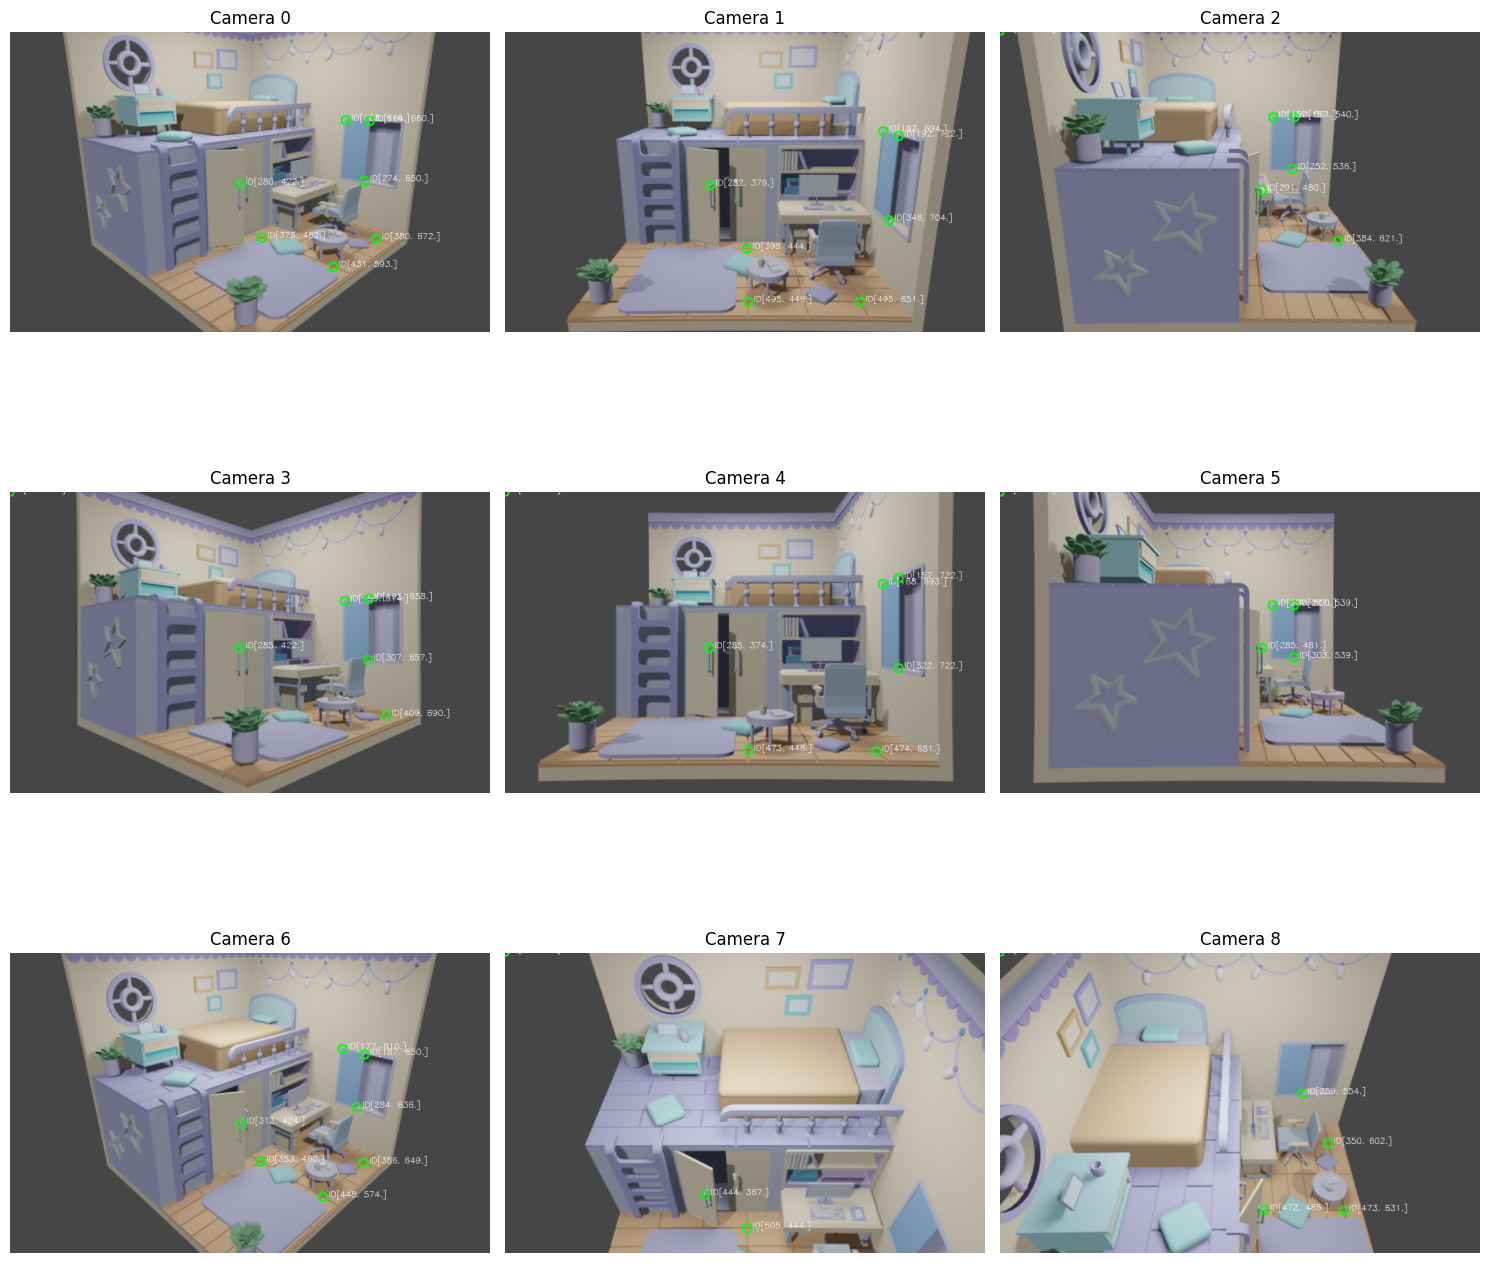

Saved: c:\Users\USER\Desktop\25-26 RPTU\3D CV\proyecto final\project\output\features_sorted.npy and c:\Users\USER\Desktop\25-26 RPTU\3D CV\proyecto final\project\output\depth_scales.npy


In [6]:
#Feature matching

def normalized_patch(gray: np.ndarray, h: float, w: float, radius: int = 5):
    """
    Extracts a window  of size radius around (h,w) and gets it prepare to be compare with other patches using NCC.
    """
   # h = int(round(h)); w = int(round(w)) #round to integer coordinates
    H, W = gray.shape #image shape
    if h < radius or w < radius or h >= H - radius or w >= W - radius:
        return None #the patch is nor going to fit in the edges (too close to the edges or too big patch) 
    patch = gray[round(h)-radius:round(h)+radius+1, round(w)-radius:round(w)+radius+1].astype(np.float32) #create a patch around the feature and save it as a vector
    patch -= patch.mean()
    n = np.linalg.norm(patch) #L2 normalization to make the patch data invariant to contrast changes
    if n < 1e-6:
        return None #the patch is almost uniform
    return (patch / n).reshape(-1) #reshapes the matrix of 2radius x radius into a 1D vector


def get_reprojection_error(pt_3d, pixel, P):
    """Reprojection error in the pixels"""
    X_hom = np.append(pt_3d, 1.0) #homogenenous coordinates
    x_proj = P @ X_hom #projection of the point in camera coordinates
    
    if abs(x_proj[2]) < 1e-6:
        return 1e6
    
    #normalization of the coordinates [u,v,1]
    u_proj = x_proj[0] / x_proj[2]
    v_proj = x_proj[1] / x_proj[2] 
    h, w = pixel
    return np.sqrt((u_proj - w)**2 + (v_proj - h)**2)


def triangulate_point(pixels, projection_matrices):
    """
    3D triangulation using all the cameras
    pixels: lista de (h, w)
    projection_matrices: matrices P (3x4)
    """
    A = []
    for (h, w), P in zip(pixels, projection_matrices):
        A.append(w * P[2, :] - P[0, :])
        A.append(h * P[2, :] - P[1, :])
    
    A = np.array(A)
    _, _, Vt = np.linalg.svd(A)
    X = Vt[-1]
    return (X / X[3])[:3]  # 3D coordinates [x,y,z,1]


def triangulation_onefeat(T_abs, K, feature, depth_u8):
    """Triangulate a feature to get the scale of depth in each image"""
    # Only keep valid images for this feature
    valid_mask = (feature[:, 0] != -1) & (feature[:, 1] != -1)
    if valid_mask.sum() < 1:
        return np.full(9, np.nan)
    
    # Build matrix A for triangulation
    A = []
    for i in np.where(valid_mask)[0]:
        h, w = feature[i]
        T_wc = np.linalg.inv(T_abs[i])
        P = K @ T_wc[:3, :]
        A.append(w * P[2, :] - P[0, :])
        A.append(h * P[2, :] - P[1, :])
    
    A = np.array(A)
    _, _, Vh = np.linalg.svd(A)
    X = Vh[-1, :]
    X = X / X[3] #[x,y,z,1] 3D coordinates triangulated (world = camera 0)
    
    # Get the real depth of the point in each camera 
    scale = np.full(9, np.nan)
    H, W = depth_u8.shape[1], depth_u8.shape[2]
    for i in range(9):
        if not valid_mask[i]:
            continue
        T_wc = np.linalg.inv(T_abs[i])
        X_ci = T_wc @ X #the triangulated point in each camera coordinates
        z_real = X_ci[2] #real depth
        
        h, w = feature[i]
        h_idx = int(np.clip(round(h), 0, H - 1))
        w_idx = int(np.clip(round(w), 0, W - 1))
        d_obs = depth_u8[i, h_idx, w_idx]  #depth in the image in the scale [0,255]
        #this satisfies the equation z_real = d_obs/255*scale
        
        if d_obs > 0 and z_real > 0:
            scale[i] = z_real * 255.0 / d_obs 
    
    return scale


def compute_scale(T_abs, K, features_sorted, depth_u8):
    """Compute a global scale for each image from the scales of all the valid features"""
    s = []
    
    for i in range(7):
        feature = features_sorted[:, i, :]
        # Solo usar features visibles en al menos 3 vistas
        if (feature[:, 0] >= 0).sum() >= 1:
            s_i = triangulation_onefeat(T_abs, K, feature, depth_u8)
            s.append(s_i)
    
    if not s:
        return np.ones(9)
    
    s = np.array(s)
    depth_scales = np.nanmedian(s, axis=0)
    
    # Rellenar NaN con valor por defecto
    depth_scales[np.isnan(depth_scales)] = 1.0
    
    return depth_scales


def sort_features_across_views(images_rgb, given_features, K, T_cw_list, 
                                patch_radius=7):
    """

    Args:
        images_rgb: 9 imágenes RGB
        given_features: (9,7,2) coordenadas (h,w) sin ordenar
        K: matriz intrínseca 3x3
        T_cw_list: lista de 9 transformaciones cámara->mundo (4x4)
        patch_radius: radio del parche
    """
    n_views, n_feat, _ = given_features.shape
    grays = [cv.cvtColor(img, cv.COLOR_RGB2GRAY) for img in images_rgb]
    
    # Camera projection matrices (world->camera)
    P_matrices = []
    for T_cw in T_cw_list:
        T_wc = np.linalg.inv(T_cw)
        P_matrices.append(K @ T_wc[:3, :])
    
    # Initialize the descriptors taking as reference camera 0 
    feature_ids = np.full((n_views, n_feat), -1, dtype=int)
    feature_ids[0] = np.arange(n_feat)
    descriptors = [[] for _ in range(n_feat)]
    for fid in range(n_feat):
        h, w = given_features[0, fid]
        desc = normalized_patch(grays[0], h, w, patch_radius)
        if desc is not None:
            descriptors[fid].append(desc)
    
    # Matching for each view
    for view_idx in range(9):
        curr_features = given_features[view_idx]
        
        #extract current valid features (avoid incorrect coordinates)
        valid_curr = []
        for j in range(n_feat):
            h, w = curr_features[j]
            if h != -1 and w != -1:
                desc = normalized_patch(grays[view_idx], h, w, patch_radius)
                if desc is not None:
                    valid_curr.append((j, desc))
        
        if not valid_curr:
            continue
        
        # Cost matrix to apply the Hungarian algorithm for the matchings
        cost_matrix = np.full((n_feat, n_feat), 1e6)
        
        for local_idx, curr_desc in valid_curr:
            curr_pixel = curr_features[local_idx]
            
            for global_id in range(n_feat):
                # Search for previous images that visited this feature
                prev_views = np.where(feature_ids[:view_idx, :] == global_id)
                
                
                if len(prev_views[0]) == 0:
                    continue
                
                best_pair_err = 1e6
                for prev_cam_idx, prev_local_idx in zip(prev_views[0], prev_views[1]):
                    feat_prev = given_features[prev_cam_idx, prev_local_idx]
                    pt_3d = triangulate_point([feat_prev, curr_pixel],[P_matrices[prev_cam_idx], P_matrices[view_idx]])
                    err = get_reprojection_error(pt_3d, feat_prev, P_matrices[prev_cam_idx]) + \
                      get_reprojection_error(pt_3d, curr_pixel, P_matrices[view_idx])
                    best_pair_err = min(best_pair_err, err)
                
                
                cost_matrix[local_idx, global_id] = best_pair_err
        
        # Hungarian algorithm for the matches
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        
        for local_idx, global_id in zip(row_ind, col_ind):
            if cost_matrix[local_idx, global_id] < 20:  # Match válido
                feature_ids[view_idx, local_idx] = global_id
                
                # Update the descriptors
                _, curr_desc = valid_curr[[j for j, _ in valid_curr].index(local_idx)]
                descriptors[global_id].append(curr_desc)
    
    # Reorganize features regarding the assigned ID's
    features_sorted = np.full((n_views, n_feat, 2), -1.0, dtype=np.float32)
    
    for view_idx in range(n_views):
        for local_idx in range(n_feat):
            global_id = feature_ids[view_idx, local_idx]
            if global_id >= 0:
                features_sorted[view_idx, global_id] = given_features[view_idx, local_idx]
    
    return features_sorted

  
# Visualization of the features across all views
def show_feature_across_views(images_rgb, features_sorted):
    """
    Args:
    images_rgb: 9 images we are working on
    features_sorted: already sorted features (7 per image)
    """
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.flatten()
    for i in range(9):
        img_rgb = cv.cvtColor(images_rgb[i], cv.COLOR_BGR2RGB)
        for j in range(7):
            gid = features_sorted[i, j]
            if gid.all() >= 0:
                h, w = features_sorted[i, j].astype(int)
                cv.circle(img_rgb, (w, h), 8, (0, 255, 0), 2)
                cv.putText(img_rgb, f"ID{gid}", (w+10, h), cv.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        axes[i].imshow(img_rgb)
        axes[i].set_title(f"Camera {i}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()


# Read RGB and depth
images_rgb = []
depth_u8   = []
for i in range(9):
    name = f"{i:02d}"
    
    img = cv.cvtColor(cv.imread(os.path.join(out_path,f"{name}.png")), cv.COLOR_BGR2RGB)
    dep = cv.imread(os.path.join(depth_path,f"{name}.png"), cv.IMREAD_UNCHANGED)  # uint8 grayscale
    images_rgb.append(img)
    depth_u8.append(dep)

depth_u8 = np.stack(depth_u8, axis=0)  # (9,H,W)

# Sort features across views
features_sorted = sort_features_across_views(images_rgb, given_features, K, world_poses, patch_radius=7)

# Compute per-image depth scales (Z_true = depth_u8 * depth_scales[i])
depth_scales = compute_scale(world_poses, K, features_sorted, depth_u8)

print("features_sorted shape:", features_sorted.shape)
print("depth_scales:", depth_scales)

# Visualize all the features matched in each image
show_feature_across_views(images_rgb, features_sorted)

#Save output
np.save(os.path.join(out_path,"features_sorted.npy"), features_sorted)
np.save(os.path.join(out_path,"depth_scales.npy"), depth_scales)
print("Saved:", os.path.join(out_path, "features_sorted.npy"), "and", os.path.join(out_path,"depth_scales.npy"))

<h2 style="color:#007b90">Step 4: Depth Map to 3D Points</h2>

Using the rescaled depth maps together with the camera poses from Step 2, compute the 3D coordinates for all pixel in each RGB image.

Saved dense world points to: c:\Users\USER\Desktop\25-26 RPTU\3D CV\proyecto final\project\output\point_cloud


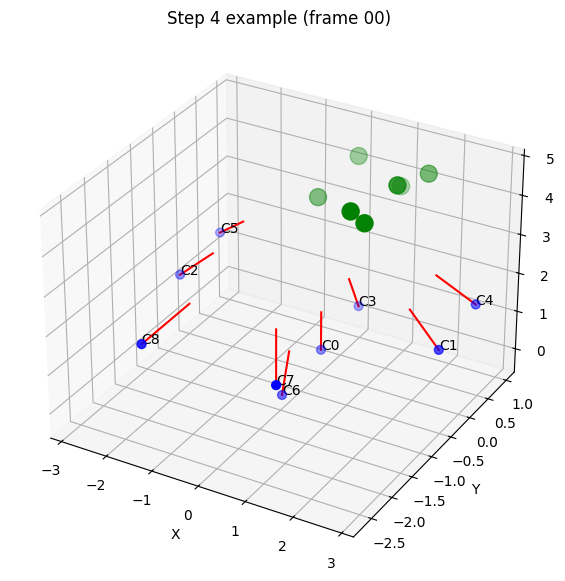

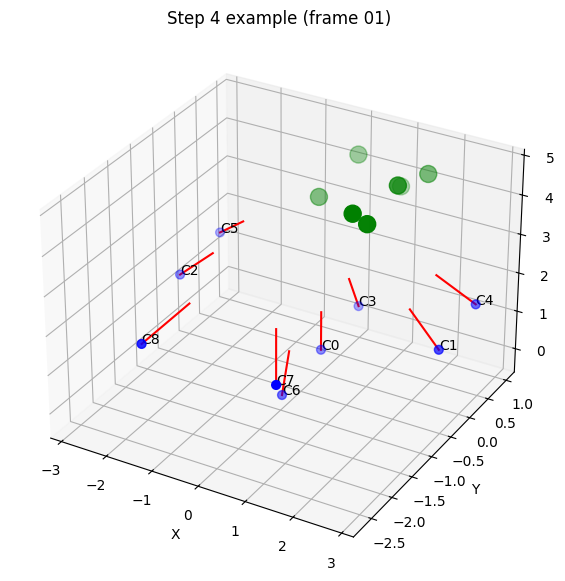

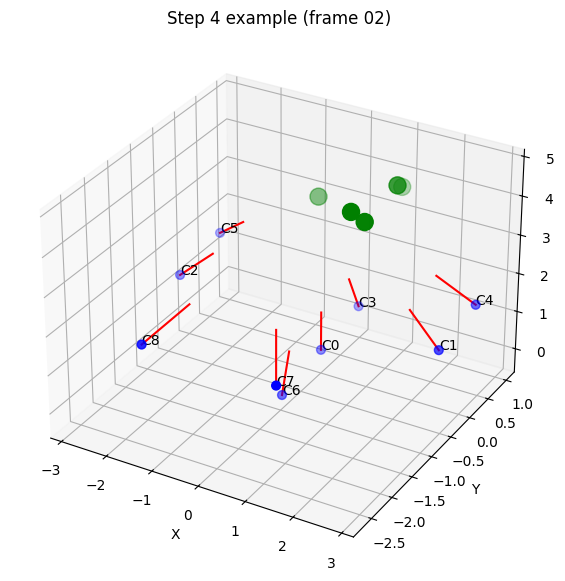

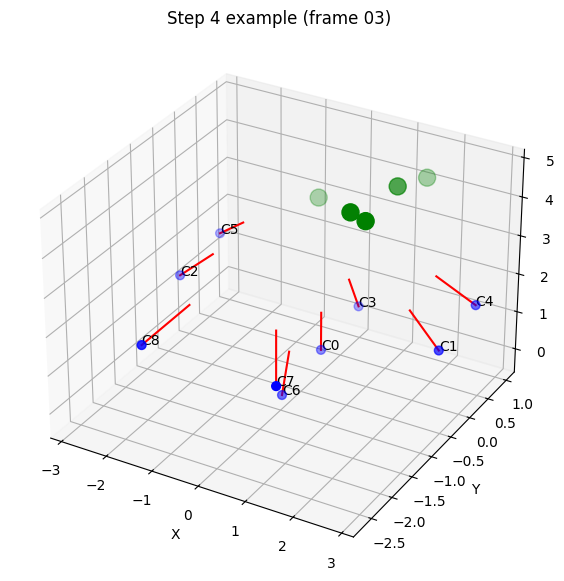

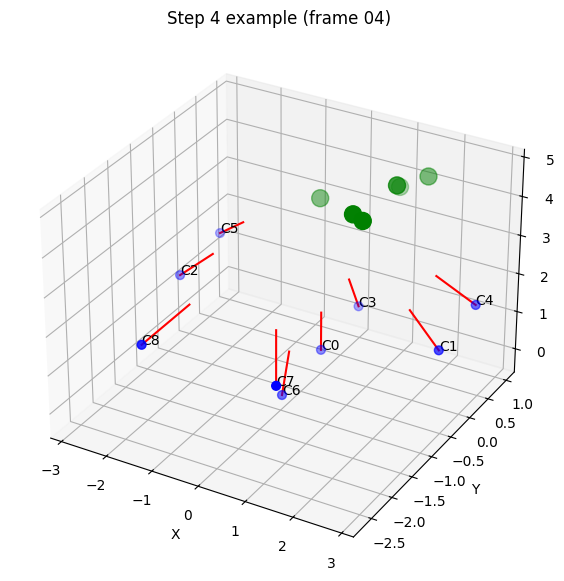

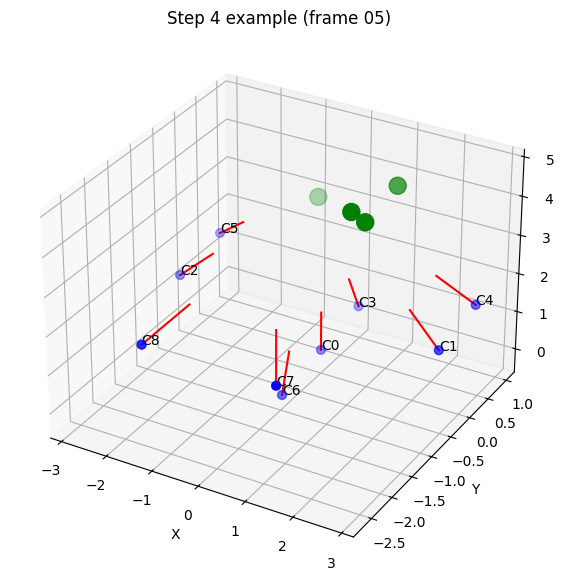

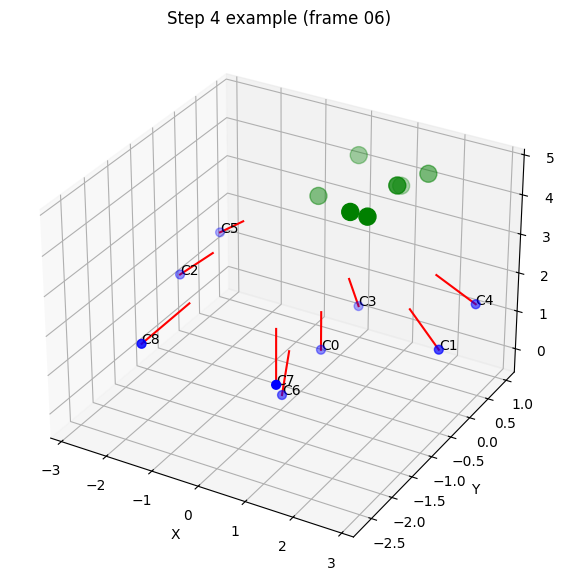

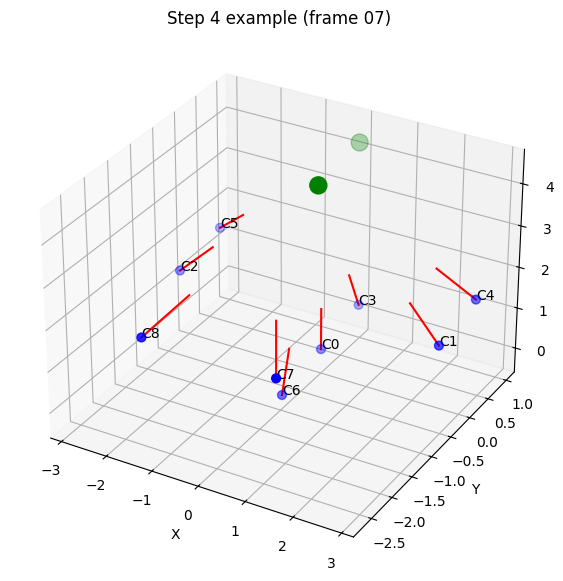

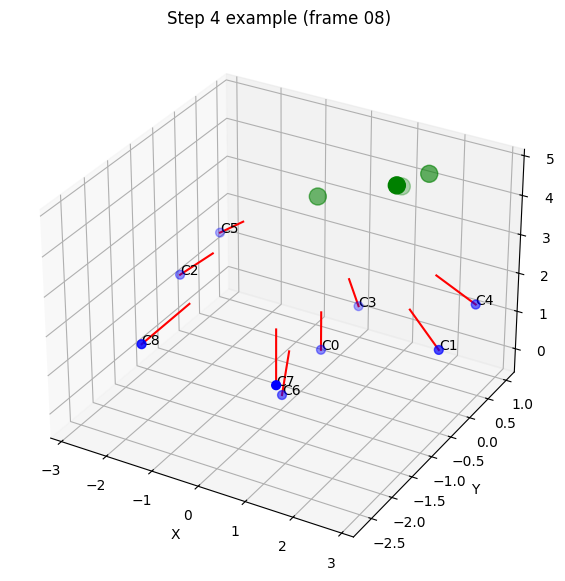

In [7]:
def compute_dense_points_world(depth_u8: np.ndarray, depth_scale: float, K_inv: np.ndarray, T_wc: np.ndarray):
    """
    depth_u8: (H,W) uint8 depth image ()
    depth_scale: scalar from Step 3 so that Z = depth_u8 * depth_scale
    K_inv: inverse intrinsics
    T_wc: 4x4 camera->world transform

    Returns:
      P_world: (H,W,3) float32, invalid depth -> NaN
    """
    H, W = depth_u8.shape
    invalid_mask = (depth_u8 == 0)
 
    depth_u8 = depth_u8.astype(np.float32) #Z_depth in each camera

    z = depth_u8/255 * depth_scale #depth scale computed in step 3
    # Pixel grid: (u,v) = (x,y) = (w,h)
    u,v = np.meshgrid(np.arange(W), np.arange(H))

    u_flat = u.reshape(-1)
    v_flat = v.reshape(-1)
    z_flat = z.reshape(-1)

    ones = np.ones_like(u_flat, dtype=np.float64)

    pix = np.stack([u_flat, v_flat, ones], axis=0).reshape(3, -1).astype(np.float64)  # (3,N) homogeneous coordinates of each pixel

    # (3,N) transformation from pixel to 3D point in the coordinates of the image
    P_cam = (K_inv @ pix)*z_flat 
    P_cam = np.vstack((P_cam, ones))

    # Coordinates change Camera -> world
    R = T_wc[:3, :3] #rotation matrix (first three columns and rows of matrix T)
    t = T_wc[:3, 3:4] #traslation vector (last column of T)
    T_rel = T_wc[:3,:]
    
    P_world =  T_rel @ P_cam  # (3,N) pixel in world coordinates
    P_world = P_world.T.reshape(H, W, 3).astype(np.float32)  
    # Mark invalid depth as NaN (depth==0 often means missing)
    P_world[depth_u8 <= 0] = np.nan
    P_world[invalid_mask] = np.nan
    return P_world


def plot_step4_example(T_abs: np.ndarray, feature_points_world: np.ndarray, title="Step 4: cameras + 7 feature points"):
    """
    feature_points_world: (M,3) points from ONE chosen image (ideally M=7)
    """
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    positions = T_abs[:, :3, 3]
    
    # plot camera centers
    ax.scatter(positions[:,0], positions[:,1], positions[:,2], color='blue', s=40)

    # plot orientation for each camera
    for i, pose in enumerate(T_abs):
        direction = draw_camera_frame(pose)
        ax.plot([positions[i,0],direction[0]],[positions[i,1],direction[1]], [positions[i,2],direction[2]], 'r')
        ax.text(positions[i,0], positions[i,1], positions[i,2], f"C{i}", fontsize=10)

    # Feature points (from one image)
    if feature_points_world.size:
        ax.scatter(feature_points_world[:, 0], feature_points_world[:, 1], feature_points_world[:, 2], s=150, c='g')

    ax.set_title(title)
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    #set_axes_equal(ax)
    plt.show()


# Load Step-3 outputs 
depth_scales_path = os.path.join(out_path, "depth_scales.npy")
features_sorted_path = os.path.join(out_path, "features_sorted.npy")

if os.path.exists(depth_scales_path):
    depth_scales = np.load(depth_scales_path, allow_pickle=True).astype(np.float64)
else:
    raise FileNotFoundError("Step 3 not executed")


if os.path.exists(features_sorted_path):
    features_sorted = np.load(features_sorted_path, allow_pickle=True).astype(np.float32)
else:
    raise FileNotFoundError("Step 3 not executed")

K_inv = np.linalg.inv(K) 
# Compute dense points for all views + save (one .npy per view)
all_dense_points = []  
for i in range(9):
    name = f"{i:02d}"
    full_depth_path = os.path.join(depth_path,f"{name}.png")
    depth_u8 = cv.imread(full_depth_path, cv.IMREAD_UNCHANGED)
    if depth_u8 is None:
        raise FileNotFoundError(f"Missing depth: {full_depth_path}")
    
    P_world = compute_dense_points_world(depth_u8, depth_scales[i], K_inv, world_poses[i])  # (H,W,3)
    np.save(os.path.join(ply_path,f"{name}_points_world.npy"), P_world)  # used in Step 5
    all_dense_points.append(P_world)

print(f"Saved dense world points to: {ply_path}")

#Step-4 example visualization: cameras + 7 feature points from one image

for frame_idx in range(9):
    name = f"{frame_idx:02d}"
    P0 = all_dense_points[frame_idx]
    feat_hw = features_sorted[frame_idx]  # (7,2) in (H,W) order, [-1,-1] if not visible
    feat_pts = []
    for (h, w) in feat_hw:
        if (h,w) == (-1,-1):
            #not visible feature
            continue
        h = int(round(h)); w = int(round(w))
        if 0<=h < P0.shape[0] and 0<=w < P0.shape[1]:
            p = P0[h, w]
            if np.isfinite(p).all():
                feat_pts.append(p)

    feat_pts = np.array(feat_pts, dtype=np.float32)
    plot_step4_example(world_poses, feat_pts, title=f"Step 4 example (frame {name})")

Feature 0: 7 obs, msx error=0.08116
Feature 1: 6 obs, msx error=0.01217
Feature 2: 6 obs, msx error=0.02376
Feature 3: 7 obs, msx error=0.09724
Feature 4: 4 obs, msx error=0.00692
Feature 5: 9 obs, msx error=0.01148
Feature 6: 8 obs, msx error=0.01756


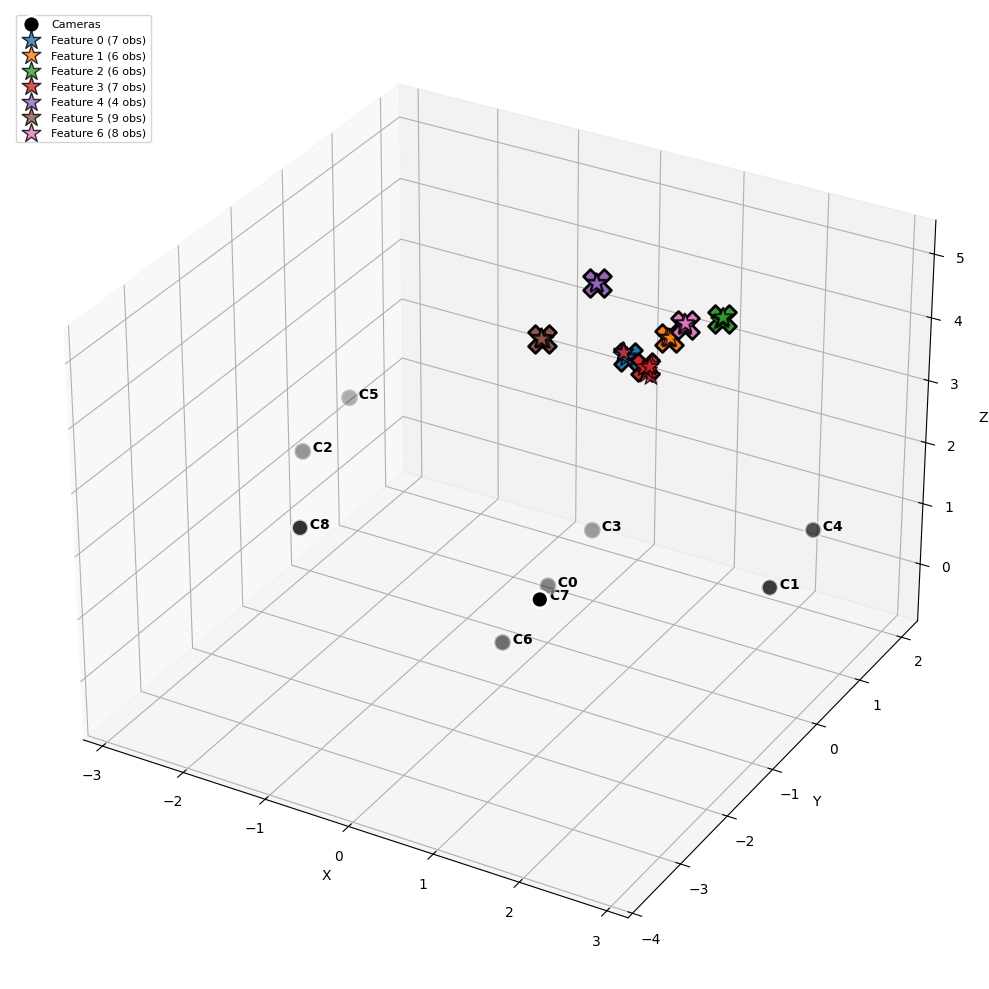

In [8]:
# VISUALIZATION HELP

def set_axes_equal(ax):
    """
    Args:
        ax: matplotlib 3D ax
    """
    x_limits = ax.get_xlim3d()  # (x_min, x_max)
    y_limits = ax.get_ylim3d()  # (y_min, y_max)
    z_limits = ax.get_zlim3d()  # (z_min, z_max)
    
    limits = np.array([x_limits, y_limits, z_limits])
    # Result: [[x_min, x_max], [y_min, y_max], [z_min, z_max]]
    
    origin = np.mean(limits, axis=1)
    # origin[0] = (x_min + x_max) / 2  → centre in X
    # origin[1] = (y_min + y_max) / 2  → centre in Y
    # origin[2] = (z_min + z_max) / 2  → centre in Z
    
    ranges = limits[:, 1] - limits[:, 0]
    # ranges[0] = x_max - x_min  → range in ax X
    # ranges[1] = y_max - y_min  → range in ax Y
    # ranges[2] = z_max - z_min  → range in ax Z
    
    max_range = np.max(ranges)
    
    radius = 0.5 * max_range

    ax.set_xlim3d([origin[0] - radius, origin[0] + radius])
    ax.set_ylim3d([origin[1] - radius, origin[1] + radius])
    ax.set_zlim3d([origin[2] - radius, origin[2] + radius])


def plot_all_features_colored_by_feature(all_dense_points, features_sorted, world_poses):
    """
    plot all the points, each feature has a color
    """
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    #plot camera centers
    camera_positions = world_poses[:, :3, 3]
    ax.scatter(camera_positions[:, 0], camera_positions[:, 1], camera_positions[:, 2],
               c='black', s=150, marker='o', label='Cameras', 
               edgecolors='white', linewidth=2, zorder=100)
    
    for i, pos in enumerate(camera_positions):
        ax.text(pos[0], pos[1], pos[2], f'  C{i}', fontsize=10, 
               color='black', weight='bold')
    
    # Colors for each feature
    colors = plt.cm.tab10(np.arange(7))
    
    for fid in range(features_sorted.shape[1]):
        feature_observations = []
        
        for view_idx in range(len(all_dense_points)):
            h, w = features_sorted[view_idx, fid]
            
            if h < 0 or w < 0:
                continue
            
            h, w = int(round(h)), int(round(w))
            P_world = all_dense_points[view_idx]
            
            if 0 <= h < P_world.shape[0] and 0 <= w < P_world.shape[1]:
                p = P_world[h, w]
                if np.isfinite(p).all():
                    feature_observations.append(p)
        
        if len(feature_observations) > 0:
            feature_observations = np.array(feature_observations)
            
            ax.scatter(feature_observations[:, 0],
                      feature_observations[:, 1],
                      feature_observations[:, 2],
                      c=[colors[fid]], s=200, marker='*', 
                      label=f'Feature {fid} ({len(feature_observations)} obs)',
                      edgecolors='black', linewidth=1, alpha=0.8)
            
            # Calcular y mostrar dispersión
            if len(feature_observations) > 1:
                std_dev = np.std(feature_observations, axis=0)
                max_error = np.max(std_dev)
                mean_pos = np.mean(feature_observations, axis=0)
                
                # Marcar posición media con X
                ax.scatter([mean_pos[0]], [mean_pos[1]], [mean_pos[2]],
                          c=[colors[fid]], s=400, marker='X',
                          edgecolors='black', linewidth=2)
                
                print(f"Feature {fid}: {len(feature_observations)} obs, "
                      f"msx error={max_error:.5f}")
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend(loc='upper left', fontsize=8)
    
    set_axes_equal(ax)
    plt.tight_layout()
    plt.show()


plot_all_features_colored_by_feature(all_dense_points,features_sorted,world_poses)
         

<h2 style="color:#007b90">Step 5: 3D Points to Point Cloud</h2>

Finally, use the provided `ply_creator` function to generate a merged colored point cloud from the computed 3D points from all images. Visualize the resulting point cloud in a viewer such as MeshLab.

Wrote: c:\Users\USER\Desktop\25-26 RPTU\3D CV\proyecto final\project\output\point_cloud\dense_colored_point_cloud.ply
Points: 681869


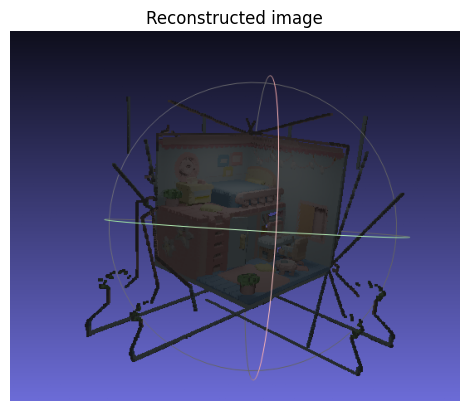

In [9]:
def voxel_downsample(points, colors, voxel_size=0.01):
    """
    points: (N,3) float
    colors: (N,3) uint8
    Returns downsampled (points, colors) by voxel grid averaging.
    """
    if voxel_size is None or voxel_size <= 0:
        return points, colors

    pts = points.astype(np.float32)
    cols = colors.astype(np.float32)

    # voxel indices
    v = np.floor(pts / voxel_size).astype(np.int32)
    # hash voxel index to 1D keys
    keys = v[:, 0].astype(np.int64) * 73856093 ^ v[:, 1].astype(np.int64) * 19349663 ^ v[:, 2].astype(np.int64) * 83492791

    order = np.argsort(keys)
    keys = keys[order]
    pts = pts[order]
    cols = cols[order]

    # group by key
    uniq, start = np.unique(keys, return_index=True)
    start = np.append(start, len(keys))

    out_pts = np.empty((len(uniq), 3), dtype=np.float32)
    out_cols = np.empty((len(uniq), 3), dtype=np.uint8)

    for i in range(len(uniq)):
        a, b = start[i], start[i+1]
        out_pts[i] = pts[a:b].mean(axis=0)
        out_cols[i] = np.clip(cols[a:b].mean(axis=0), 0, 255).astype(np.uint8)

    return out_pts, out_cols



# controls 
stride = 2              # 1 = full resolution (big), 2/3/4 = smaller
voxel_size = None       # meters-ish; set None to disable
max_points = None       # e.g. 2_000_000 to cap; or None for no cap

all_pts = []
all_rgb = []

for i in range(9):
    name = f"{i:02d}"
    # Load dense world points saved in Step 4
    pts_path = os.path.join(ply_path, f"{name}_points_world.npy")
    if not os.path.exists(pts_path):
        raise FileNotFoundError(f"Missing {pts_path}. Run Step 4 first to generate it.")
    P_world = np.load(pts_path)  # (H,W,3), NaNs for invalid
    
    # Load RGB image (same resolution as the points)
    img_rgb = os.path.join(out_path, f"{name}.png")

    rgb = cv.cvtColor(cv.imread(img_rgb), cv.COLOR_BGR2RGB)

    # Downsample both consistently
    P_s = P_world[::stride, ::stride, :]
    rgb_s = rgb[::stride, ::stride, :]
    depth_s = depth_u8[::stride, ::stride]

    d_max = P_s[:,:,2].max()*0.85
    d_min = 0
    rgb_min = 215
    
    # Keep only valid points (only points that are not too near or too far, to try eliminating the black frame around the images)
    mask_max = ((P_s[:, :, 2] < d_max) & (P_s[:,:,2]>d_min))
    color_mask = (rgb_s.sum(axis=2)> rgb_min)

    #valid_indices = np.where(mask_max)
    valid_indices = np.where(color_mask & mask_max)
    pts = P_s[valid_indices]
    cols = rgb_s[valid_indices]

    all_pts.append(pts)
    all_rgb.append(cols)
    

points = np.concatenate(all_pts, axis=0)
colors = np.concatenate(all_rgb, axis=0)
points_ds, colors_ds = voxel_downsample(points, colors, voxel_size=voxel_size)

out_ply = os.path.join(ply_path,"dense_colored_point_cloud.ply")
ply_creator(points_ds, colors_ds, str(out_ply))

print("Wrote:", out_ply)
print("Points:", points.shape[0])

res_path = os.path.join(data_path, "reconstruction.png")
img = mpimg.imread(res_path)
plt.title("Reconstructed image")
plt.imshow(img)
plt.axis("off")
plt.show()
 